In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
STRUCTURED_PATH = "../data/processed/structured_b_clean.csv"
FUSION_PATH = "../data/processed/fusion_dataset.csv"

# Load
df_struct = pd.read_csv(STRUCTURED_PATH)
df_fusion = pd.read_csv(FUSION_PATH)

# Preview
df_struct.head(), df_fusion.head()

(   bed  bath    sqft        city        state     price
 0  3.0   2.0   920.0    Adjuntas  Puerto Rico  105000.0
 1  4.0   2.0  1527.0    Adjuntas  Puerto Rico   80000.0
 2  2.0   1.0   748.0  Juana Diaz  Puerto Rico   67000.0
 3  4.0   2.0  1800.0       Ponce  Puerto Rico  145000.0
 4  6.0   2.0  1760.0    Mayaguez  Puerto Rico   65000.0,
    image_id  bed  bath  sqft             city   price  \
 0         0    3   2.0  1560  Salton City, CA  201900   
 1         1    3   2.0   713      Brawley, CA  228500   
 2         2    3   1.0   800     Imperial, CA  273950   
 3         3    3   1.0  1082      Brawley, CA  350000   
 4         4    4   3.0  2547     Calexico, CA  385100   
 
                  image_path  
 0  ../data/raw/images\0.jpg  
 1  ../data/raw/images\1.jpg  
 2  ../data/raw/images\2.jpg  
 3  ../data/raw/images\3.jpg  
 4  ../data/raw/images\4.jpg  )

In [2]:
print("Structured Dataset Info:")
print(df_struct.info())

print("\nFusion Dataset Info:")
print(df_fusion.info())

Structured Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2202561 entries, 0 to 2202560
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   bed     float64
 1   bath    float64
 2   sqft    float64
 3   city    object 
 4   state   object 
 5   price   float64
dtypes: float64(4), object(2)
memory usage: 100.8+ MB
None

Fusion Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15474 entries, 0 to 15473
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_id    15474 non-null  int64  
 1   bed         15474 non-null  int64  
 2   bath        15474 non-null  float64
 3   sqft        15474 non-null  int64  
 4   city        15474 non-null  object 
 5   price       15474 non-null  int64  
 6   image_path  15474 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 846.4+ KB
None


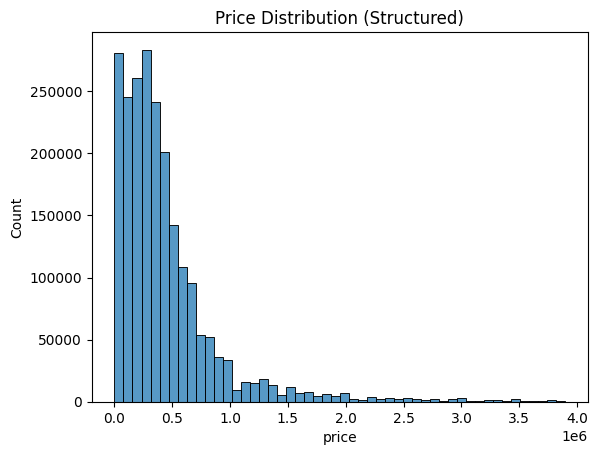

In [3]:
plt.figure()
sns.histplot(df_struct["price"], bins=50)
plt.title("Price Distribution (Structured)")
plt.show()

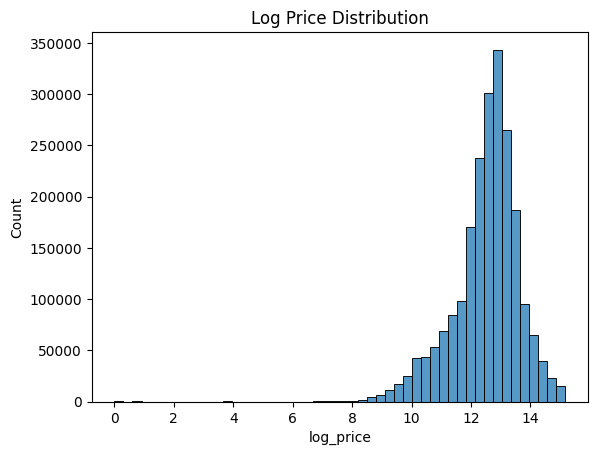

In [4]:
import numpy as np

df_struct["log_price"] = np.log1p(df_struct["price"])
df_fusion["log_price"] = np.log1p(df_fusion["price"])

plt.figure()
sns.histplot(df_struct["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.show()

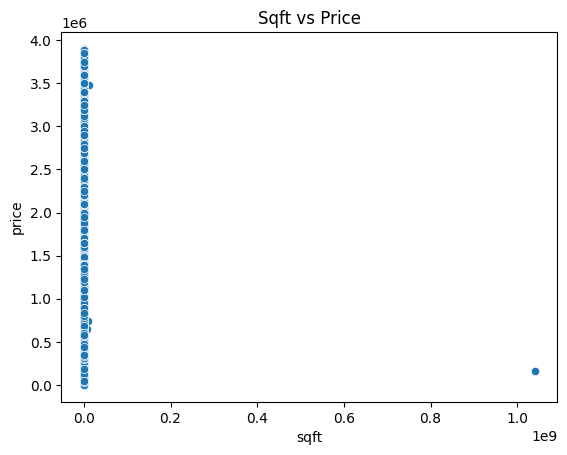

In [5]:
sns.scatterplot(x="sqft", y="price", data=df_struct)
plt.title("Sqft vs Price")
plt.show()

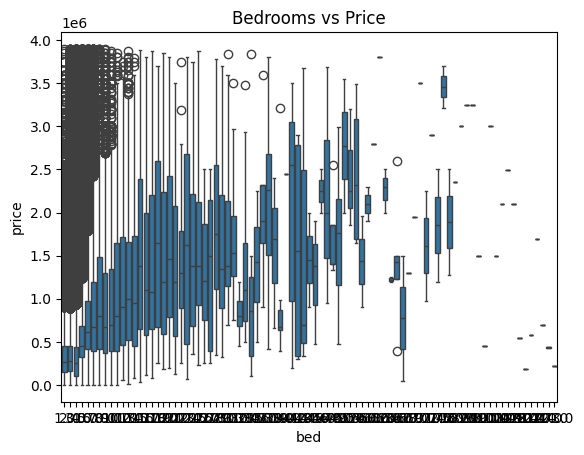

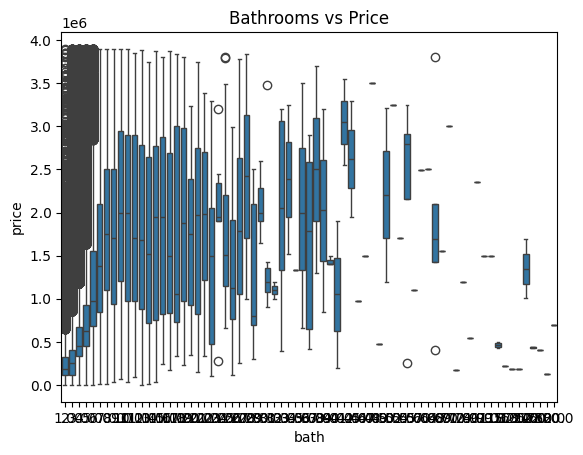

In [6]:
sns.boxplot(x="bed", y="price", data=df_struct)
plt.title("Bedrooms vs Price")
plt.show()

sns.boxplot(x="bath", y="price", data=df_struct)
plt.title("Bathrooms vs Price")
plt.show()

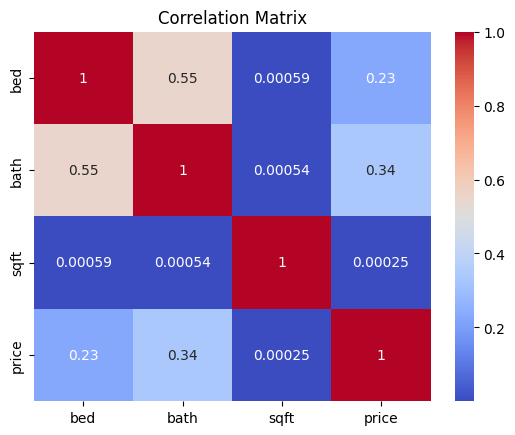

In [7]:
corr = df_struct[["bed", "bath", "sqft", "price"]].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

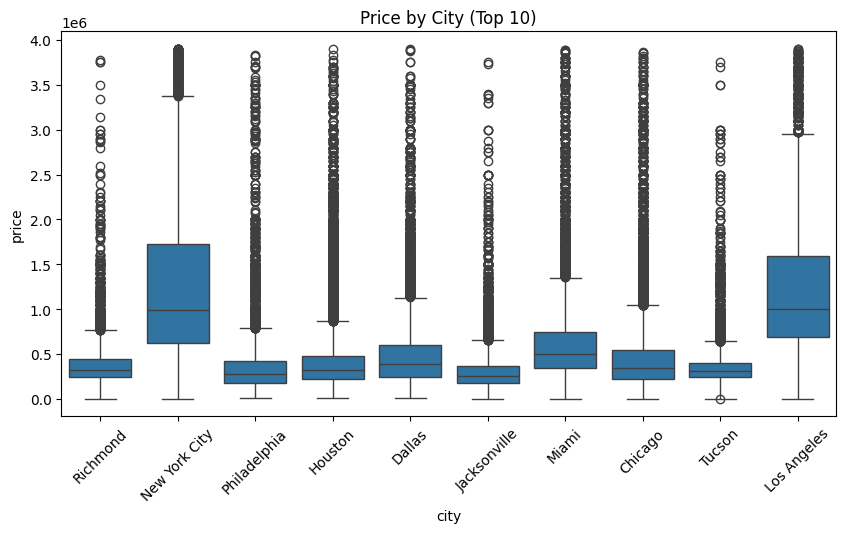

In [8]:
top_cities = df_struct["city"].value_counts().head(10).index

df_top = df_struct[df_struct["city"].isin(top_cities)]

plt.figure(figsize=(10,5))
sns.boxplot(x="city", y="price", data=df_top)
plt.xticks(rotation=45)
plt.title("Price by City (Top 10)")
plt.show()

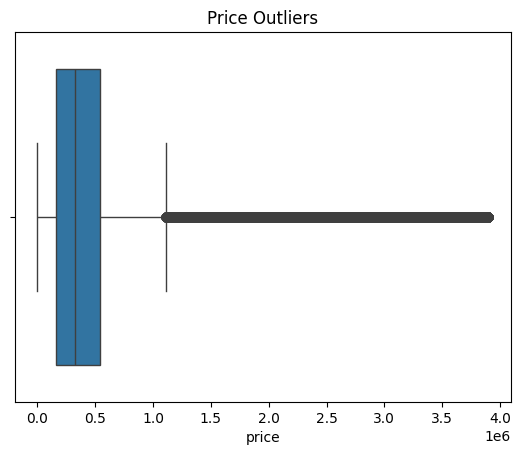

In [9]:
sns.boxplot(x=df_struct["price"])
plt.title("Price Outliers")
plt.show()

In [10]:
q_low = df_struct["price"].quantile(0.01)
q_high = df_struct["price"].quantile(0.99)

df_struct = df_struct[(df_struct["price"] > q_low) & (df_struct["price"] < q_high)]

In [12]:
import os

FIG_PATH = "../outputs/figures"
os.makedirs(FIG_PATH, exist_ok=True)

plt.figure()
sns.histplot(df_struct["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.savefig(f"{FIG_PATH}/log_price_dist.png")
plt.close()